# System

6-qubit, 30-layer system.

The VQE config is:

```json
"config":{"run":"vqe","nqubits":6,"state":"dmatrix","output":{"file_name_prefix":"xy_ansatz_time_depol_trotter_tmax_various","draw":{"status":false,"fig_dpi":100,"type":"png"}},"observable":{"def":"ising","coefficients":{"cn":[0.5,0.5,0.5,0.5,0.5],"bn":[1.0,1.0,1.0,1.0,1.0,1.0],"r":1}},"ansatz":{"layer":30,"gateset":1,"ugate":{"type":"xy-iss","coefficients":{"cn":[0.5,0.5,0.5,0.5,0.5],"bn":[0,0,0,0,0,0],"r":0},"time":{"min":0.0,"max":20}}},"vqe":{"iteration":10,"optimization":{"status":true,"algorithm":"SLSQP","constraint":true}},"init_param":{"value":"random"},"noise_profile":{"status":true,"type":"<time-depol-trotter> vs <time-depol>","noise_prob":[0,0,0.001,0],"noise_on_init_param":{"status":false,"value":0}},"redundant":{"identity_factors":[[0,0,0,0],[1,1,1,1]]},"zne":{"method":"richardson","degree":1,"sampling":"default","data_points":null}}
```

NOTE: Parameter delta_t was directly accessed in ansatz.py script.

---

# Import

In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
from pathlib import Path

# --- Third-Party Libraries ---
import matplotlib.pyplot as plt

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.misc import load_simulation_tree
from nbutils.master import *

In [2]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({
"font.family":      "serif",
"mathtext.fontset": "dejavuserif",
"axes.linewidth":   0.8,
"xtick.direction":  "in",
"ytick.direction":  "in",
"xtick.top":        True,
"ytick.right":      True,
"xtick.major.size": 4,
"ytick.major.size": 4,
"xtick.minor.size": 2,
"ytick.minor.size": 2,
"xtick.minor.visible": True,
"ytick.minor.visible": True,
"xtick.labelsize":  8,   # ✓ already here
"ytick.labelsize":  8,   # ✓ already here
"axes.labelsize":   8,   # ← add this (xlabel / ylabel)
"legend.fontsize":  8,   # ← add this (legend text)
"font.size":        8,   # ← add this (global fallback)
})

# Variables

In [3]:
# Usage
BASE_DIR = "data/6Q-trotter"
RAW_SIM_DATA = load_simulation_tree(BASE_DIR)

EXACT_SOL :float = -7.29622981055876

width_px = 2070
height_px = 1571
dpi = 600

FIG_SIZE_IEEE_DOUBLE = (width_px / dpi, height_px / dpi)
MASTER_EXPORT_DIR = "reports/6Q-trotter/"

In [4]:
RAW_SIM_DATA.keys()

dict_keys(['time-depol-trotter', 'time-depol', 'p0.0001', 'p0.001', 'p0.01'])

In [5]:
RAW_SIM_DATA["time-depol-trotter"].keys()

dict_keys(['trotter_xy_ansatz_time_depol_p0.001_delt_0.01_tmax_20_20260811_170235', 'trotter_xy_ansatz_time_depol_p0.001_delt_0.03_tmax_20_20260812_102100', 'trotter_xy_ansatz_time_depol_p0.001_delt_0.05_tmax_20_20260812_144833', 'trotter_xy_ansatz_time_depol_p0.001_delt_0.1_tmax_20_20260812_191015'])

---

# Raw Data Processing Before Plotting

In [6]:
PROCESSED_SIM_DATA = {'time-depol-trotter': {}}

for run_group, subfolders in RAW_SIM_DATA['time-depol-trotter'].items():

    # ── delta_t: grab from any one VQE file ──────────────────────────────────
    vqe_content = next(iter(subfolders['VQE'].values()))
    delta_t = vqe_content['others']['lie_trotter_details'][0]['delta_t']

    # ── sorted_expectation_vals: only ZNE files (skip REDUNDANT) ─────────────
    all_vals = []
    sorted_noise = None

    for run_key, run_content in subfolders['ZNE'].items():
        if not run_key.endswith('_ZNE'):
            continue
        others = run_content['output']['zne_values']['others']
        all_vals.append(others['sorted_expectation_vals'])
        if sorted_noise is None:
            sorted_noise = others['sorted_noise']

    arr = np.array(all_vals)  # shape: (n_runs, n_noise_levels)

    PROCESSED_SIM_DATA['time-depol-trotter'][run_group] = {
        'delta_t':      delta_t,
        'sorted_noise': sorted_noise,
        #'sorted_noise_norm': [val/6 for val in sorted_noise],  # Normalize noise levels
        'mean':         arr.mean(axis=0).tolist(),
        'std':          arr.std(axis=0, ddof=1).tolist(),
        'n_runs':       len(all_vals),
    }

# Sanity check
for group, stats in PROCESSED_SIM_DATA['time-depol-trotter'].items():
    print(f"\n{group}")
    print(f"  delta_t : {stats['delta_t']}  n_runs={stats['n_runs']}")
    print(f"  noise   : {stats['sorted_noise']}")
    #print(f"  noise_norm : {stats['sorted_noise_norm']}")
    print(f"  mean    : {[round(v,4) for v in stats['mean']]}")
    print(f"  std     : {[round(v,4) for v in stats['std']]}")


trotter_xy_ansatz_time_depol_p0.001_delt_0.01_tmax_20_20260811_170235
  delta_t : 0.01  n_runs=10
  noise   : [1, 3, 5, 7, 9, 11]
  mean    : [-6.5386, -5.2921, -4.2873, -3.4767, -2.8222, -2.2933]
  std     : [0.0284, 0.0636, 0.0868, 0.1005, 0.1074, 0.1093]

trotter_xy_ansatz_time_depol_p0.001_delt_0.03_tmax_20_20260812_102100
  delta_t : 0.03  n_runs=10
  noise   : [1, 3, 5, 7, 9, 11]
  mean    : [-6.5697, -5.3792, -4.4105, -3.6213, -2.9776, -2.4519]
  std     : [0.029, 0.0685, 0.0942, 0.1092, 0.1166, 0.1185]

trotter_xy_ansatz_time_depol_p0.001_delt_0.05_tmax_20_20260812_144833
  delta_t : 0.05  n_runs=10
  noise   : [1, 3, 5, 7, 9, 11]
  mean    : [-6.5697, -5.3657, -4.3884, -3.5942, -2.948, -2.4217]
  std     : [0.0308, 0.0761, 0.1055, 0.1228, 0.1314, 0.1338]

trotter_xy_ansatz_time_depol_p0.001_delt_0.1_tmax_20_20260812_191015
  delta_t : 0.1  n_runs=10
  noise   : [1, 3, 5, 7, 9, 11]
  mean    : [-6.5736, -5.3729, -4.3971, -3.6032, -2.9566, -2.4294]
  std     : [0.0316, 0.0836, 

In [7]:
run_group, subfolders in RAW_SIM_DATA['time-depol'].items()

('trotter_xy_ansatz_time_depol_p0.001_delt_0.1_tmax_20_20260812_191015', False)

In [8]:
PROCESSED_SIM_DATA['time-depol'] = {}
for run_group, subfolders in RAW_SIM_DATA['time-depol'].items():

    all_vals = []
    sorted_noise = None

    for run_key, run_content in subfolders['ZNE'].items():
        if not run_key.endswith('_ZNE'):
            continue
        others = run_content['output']['zne_values']['others']
        all_vals.append(others['sorted_expectation_vals'])
        if sorted_noise is None:
            sorted_noise = others['sorted_noise']

    arr = np.array(all_vals)

    PROCESSED_SIM_DATA['time-depol'][run_group] = {
        'sorted_noise': sorted_noise,
        #'sorted_noise_norm': [val/6 for val in sorted_noise],  # Normalize noise levels
        'mean':         arr.mean(axis=0).tolist(),
        'std':          arr.std(axis=0, ddof=1).tolist(),
        'n_runs':       len(all_vals),
    }

# Sanity check
for group, stats in PROCESSED_SIM_DATA['time-depol'].items():
    print(f"\n{group}")
    print(f"  n_runs={stats['n_runs']}")
    print(f"  noise : {stats['sorted_noise']}")
    print(f"  mean  : {[round(v,4) for v in stats['mean']]}")
    print(f"  std   : {[round(v,4) for v in stats['std']]}")


no_trotter_xy_ansatz_time_depol_p0.0001_tmax_20_20260810_224319
  n_runs=10
  noise : [1, 3, 5, 7, 9, 11]
  mean  : [-6.5901, -5.4018, -4.433, -3.6424, -2.9965, -2.4682]
  std   : [0.0337, 0.0784, 0.1076, 0.1249, 0.1336, 0.1361]


---

# Plotting

## Plotting Function

In [9]:
_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "h", "<", ">"]

def plot_data(
    data_list:       list,
    series:          list,
    output_dir:      str,
    file_name:       str,
    exact_color:     str   = "magenta",
    unmit_color:     str   = "gray",
    extrapol_target: float = 0,
    figsize:         tuple = (7, 5),
    dpi:             int   = 600,
    save_format:     str   = "png",
    xlabel:          str   = r"Scale factor",
    ylabel:          str   = r"Min. $\langle H_{\mathrm{Ising}} \rangle$",
    fontsize:        int   = 8,
    marker_size:     float = 6,
    capsize:         int   = 4,
    border_width:    float = 1.5,
    legend_loc:      str   = "best",
    show_plot:       bool  = False,
) -> plt.Figure:

    os.makedirs(output_dir, exist_ok=True)
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, layout="constrained")
    ax.set_axisbelow(True)

    legend_handles = []
    exact_drawn = False

    for i, (data, s) in enumerate(zip(data_list, series)):
        c            = s["color"]
        noisy_marker = s.get("marker", _MARKERS[i % len(_MARKERS)])
        zne_marker   = s.get("zne_marker", "*")
        label        = f"{s['label']} ($\\Delta t = {s['delta_t']}$)" if 'delta_t' in s else s['label']

        h = ax.errorbar(
            data["sorted_noise"], data["mean"], yerr=data["std"],
            fmt=noisy_marker, color=c, ecolor=c, capsize=capsize,
            markersize=marker_size, label=label,
        )
        legend_handles.append(h)

        # ZNE diamond / star
        # ax.errorbar(
        #     np.atleast_1d(extrapol_target), np.atleast_1d(data["zne_mean"]),
        #     yerr=np.atleast_1d(data["zne_std"]),
        #     fmt=zne_marker, color=c, ecolor=c, capsize=capsize,
        #     markersize=marker_size, zorder=4,
        # )

        if not exact_drawn:
            h_e = ax.axhline(
                EXACT_SOL, color=exact_color,
                linestyle="--", linewidth=1.5, label=f"Exact solution: {EXACT_SOL:.4f}", zorder=1,
            )
            legend_handles.append(h_e)
            exact_drawn = True

    # legend_handles.append(
    #     Line2D([0], [0], marker="*", color="black", linestyle="None",
    #            markersize=marker_size, label="ZNE extrapolated")
    # )
    
    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_xlim(left=0)
    # ── exact x-axis ticks ──────────────────────────────────────────────
    all_x = sorted(set(
        float(x) for data in data_list for x in data["sorted_noise"]
    ))
    ax.set_xticks(all_x)
    ax.tick_params(labelsize=fontsize)
    ax.grid(True, linestyle="-", alpha=0.7)
    ax.legend(
        handles=legend_handles,
        loc=legend_loc,
        fontsize=fontsize,
        frameon=True,
        framealpha=1.0,
        edgecolor="black",
        fancybox=False,
        borderpad=0.5,
        labelspacing=0.3,
    )
    for spine in ax.spines.values():
        spine.set_linewidth(border_width)

    path = os.path.join(output_dir, f"{os.path.splitext(file_name)[0]}.{save_format}")
    fig.savefig(path, format=save_format, dpi=dpi)
    print(f"✅ Saved: {path}")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)
    return fig


## Plotting: Trotter Vs No-Trotter

✅ Saved: reports/6Q-trotter/COMPARISION_TROTTER_VS_NO_TROTTER_6-QUBIT_SCALE_FACTOR.png


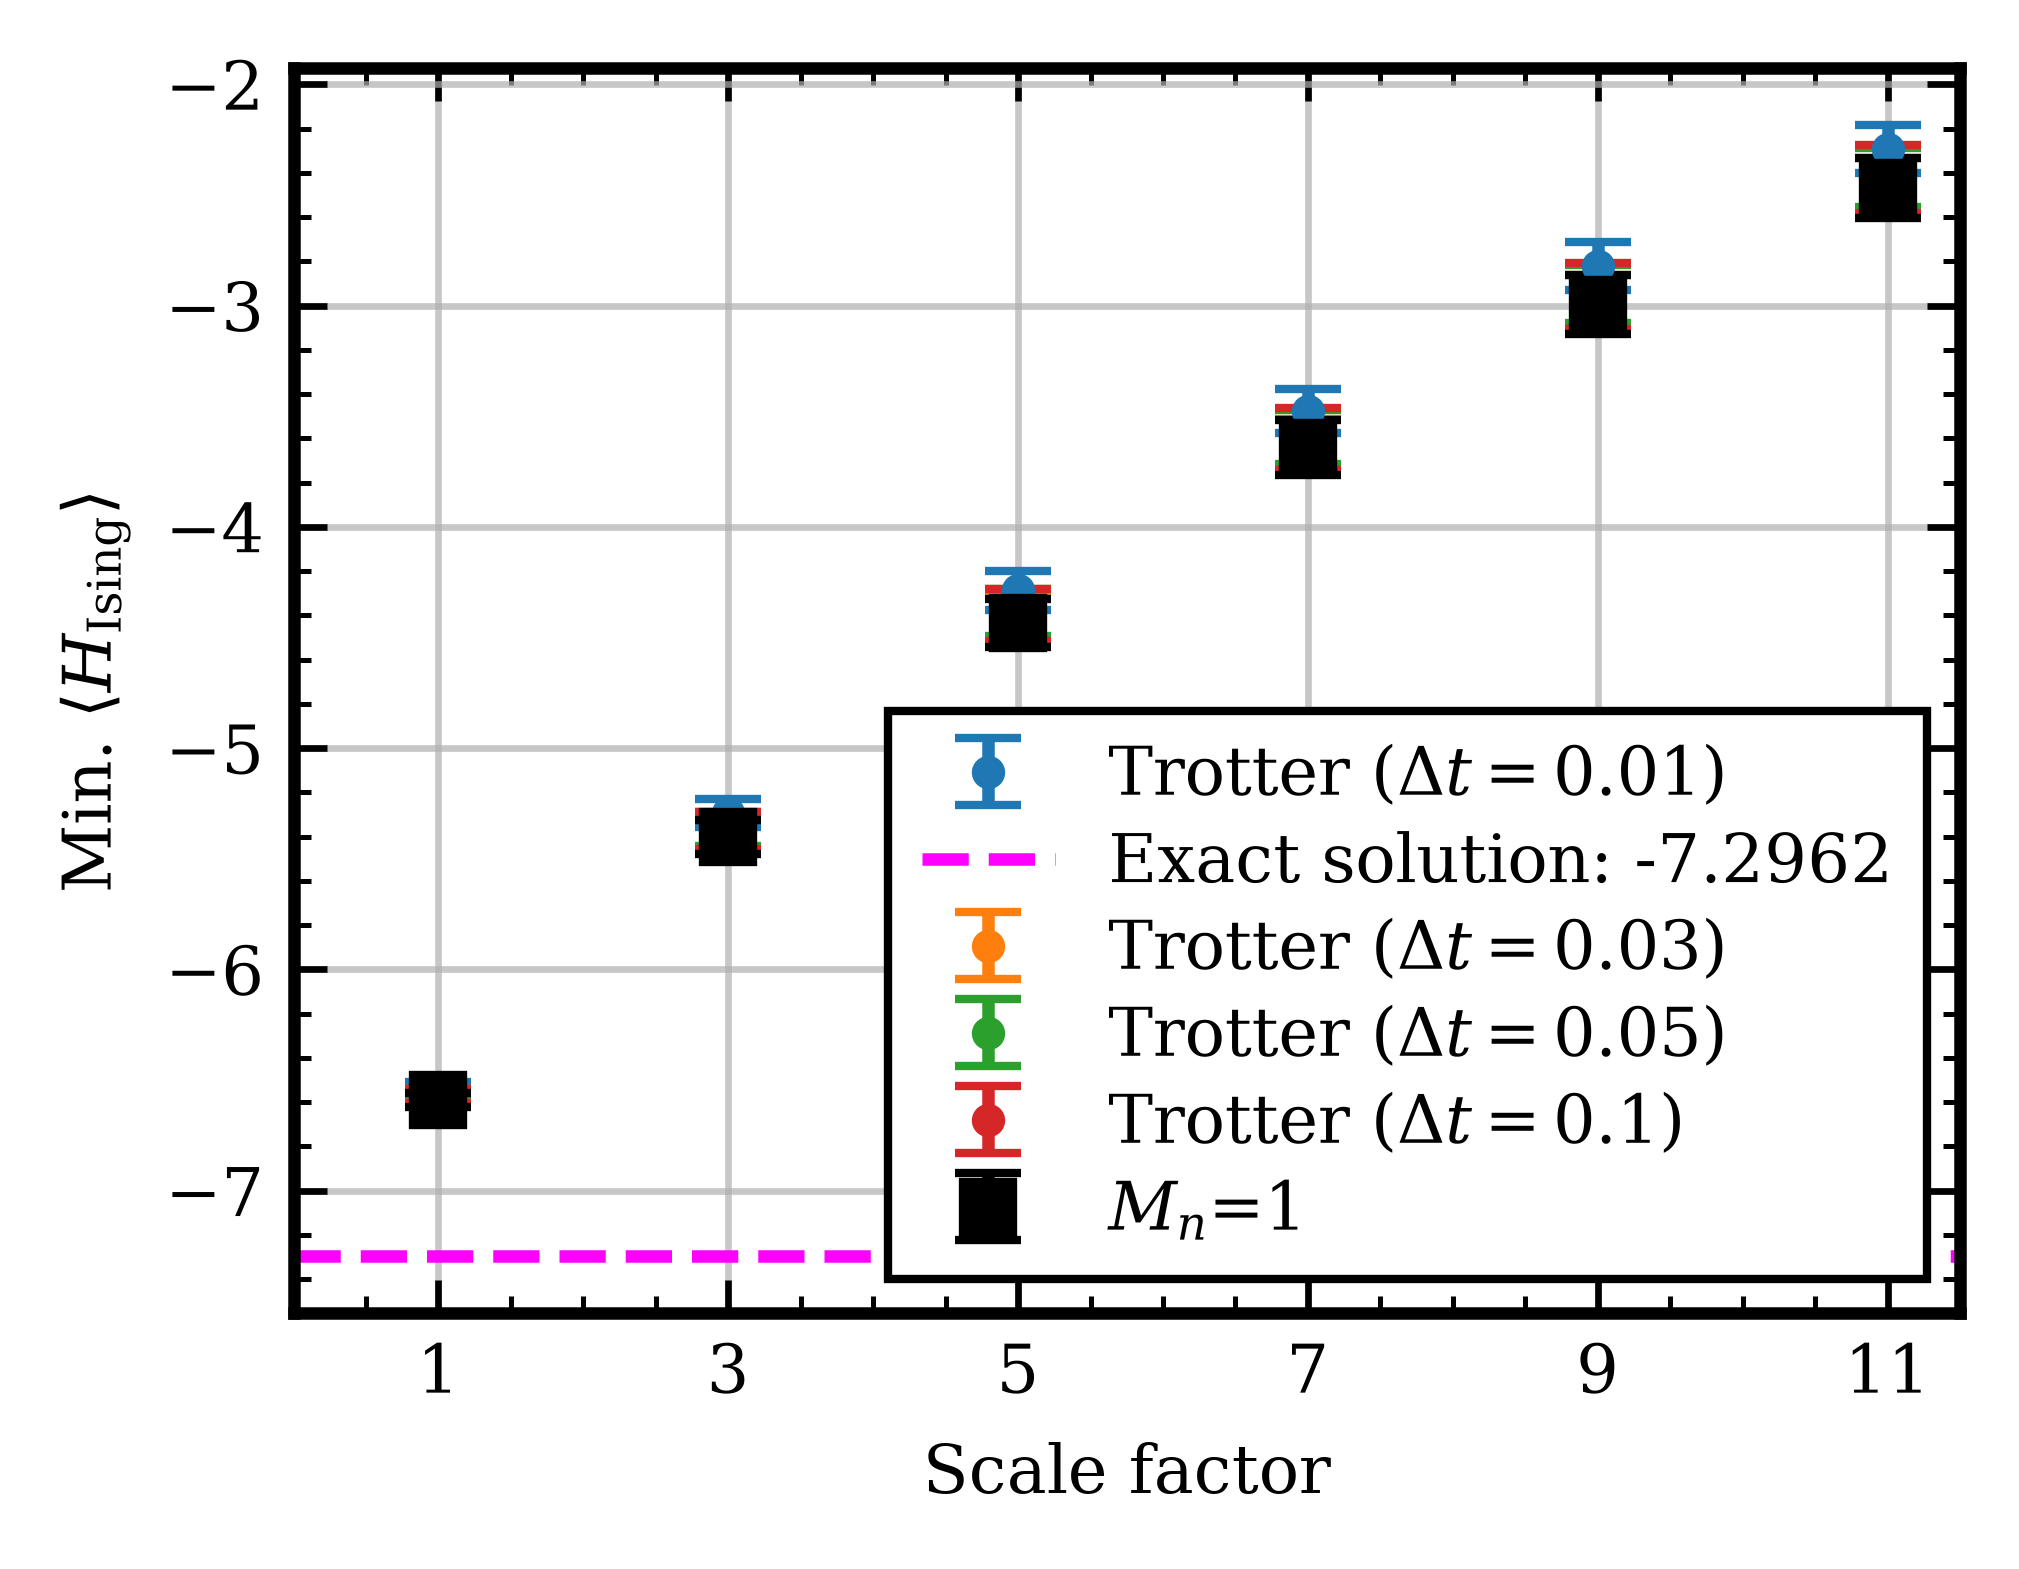

In [10]:
# ── Call site ─────────────────────────────────────────────────────────────────
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

data_list = []
series    = []

# time-depol-trotter — circle marker, one per delta_t
for i, (run_group, stats) in enumerate(PROCESSED_SIM_DATA['time-depol-trotter'].items()):
    data_list.append(stats)
    series.append({
        "label":   "Trotter",
        "color":   colors[i % len(colors)],
        "delta_t": stats["delta_t"],
        "marker":  ".",
    })

# time-depol — square marker, no delta_t
for run_group, stats in PROCESSED_SIM_DATA['time-depol'].items():
    data_list.append(stats)
    series.append({
        "label":  r"$M_n$=1",
        "color":  "black",
        "marker": "s",
    })
plot_data(
    data_list=data_list,
    series=series,
    show_plot=False,
    output_dir  = MASTER_EXPORT_DIR,
    file_name   = "COMPARISION_TROTTER_VS_NO_TROTTER_6-QUBIT_SCALE_FACTOR",
    figsize     = (3.25, 2.5),
    dpi         = 600,
)

---

# Across various $\gamma$

In [11]:
NOISE_KEYS = ['p0.0001', 'p0.001', 'p0.01']
processed  = {}

def get_trotter_key(d):
    for k in d:
        if 'trotter' in k or 'teotter' in k:
            return k

for noise_key in NOISE_KEYS:
    data = RAW_SIM_DATA[noise_key]

    # --- time-depol ---
    depol_results = []
    first = next(iter(data['time-depol'].values()))
    if 'config' in first:
        # flat: all runs are directly under time-depol (p0.001 case)
        runs    = data['time-depol'].values()
        costs   = [r["output"]["optimized_minimum_cost"][0] for r in runs]
        ref     = next(iter(runs))
        depol_p = ref["config"]["noise_profile"]["noise_prob"][2]
        depol_results.append({
            "depol_p":  depol_p,
            "vqe_mean": float(np.mean(costs)),
            "vqe_std":  float(np.std(costs)),
        })
    else:
        # nested: time-depol -> folder -> runs
        for folder_name, folder_data in data['time-depol'].items():
            costs   = [r["output"]["optimized_minimum_cost"][0] for r in folder_data.values()]
            ref     = next(iter(folder_data.values()))
            depol_p = ref["config"]["noise_profile"]["noise_prob"][2]
            depol_results.append({
                "depol_p":  depol_p,
                "vqe_mean": float(np.mean(costs)),
                "vqe_std":  float(np.std(costs)),
            })

    # --- time-depol-trotter ---
    trotter_results = []
    trotter_key = get_trotter_key(data)
    for folder_name, folder_data in data[trotter_key].items():
        costs   = [r["output"]["optimized_minimum_cost"][0] for r in folder_data.values()]
        ref     = next(iter(folder_data.values()))
        depol_p = ref["config"]["noise_profile"]["noise_prob"][2]
        del_t   = ref["others"]["lie_trotter_details"][0]["delta_t"]
        trotter_results.append({
            "depol_p":  depol_p,
            "del_t":    del_t,
            "vqe_mean": float(np.mean(costs)),
            "vqe_std":  float(np.std(costs)),
        })

    processed[noise_key] = {
        "time-depol":         sorted(depol_results,   key=lambda x: x["depol_p"]),
        "time-depol-trotter": sorted(trotter_results, key=lambda x: (x["depol_p"], x["del_t"])),
    }

In [12]:
processed

{'p0.0001': {'time-depol': [{'depol_p': 0.0001,
    'vqe_mean': -7.19885985779969,
    'vqe_std': 0.012577918501882574}],
  'time-depol-trotter': [{'depol_p': 0.0001,
    'del_t': 0.01,
    'vqe_mean': -7.19290492753395,
    'vqe_std': 0.010254451751648986},
   {'depol_p': 0.0001,
    'del_t': 0.03,
    'vqe_mean': -7.194136163316697,
    'vqe_std': 0.00786578443831011},
   {'depol_p': 0.0001,
    'del_t': 0.05,
    'vqe_mean': -7.191188733235135,
    'vqe_std': 0.008641918501795208},
   {'depol_p': 0.0001,
    'del_t': 0.1,
    'vqe_mean': -7.191321360204808,
    'vqe_std': 0.012958354040559105}]},
 'p0.001': {'time-depol': [{'depol_p': 0.001,
    'vqe_mean': -6.590113023612429,
    'vqe_std': 0.03199762174053921}],
  'time-depol-trotter': [{'depol_p': 0.001,
    'del_t': 0.01,
    'vqe_mean': -6.53812471635261,
    'vqe_std': 0.02702911426510688},
   {'depol_p': 0.001,
    'del_t': 0.03,
    'vqe_mean': -6.569389076611633,
    'vqe_std': 0.027555118077928036},
   {'depol_p': 0.001,
 

✅ Saved: reports/6Q-trotter/COMPARISION_TROTTER_VS_NO_TROTTER_6-QUBIT_VARY_GAMMA.png


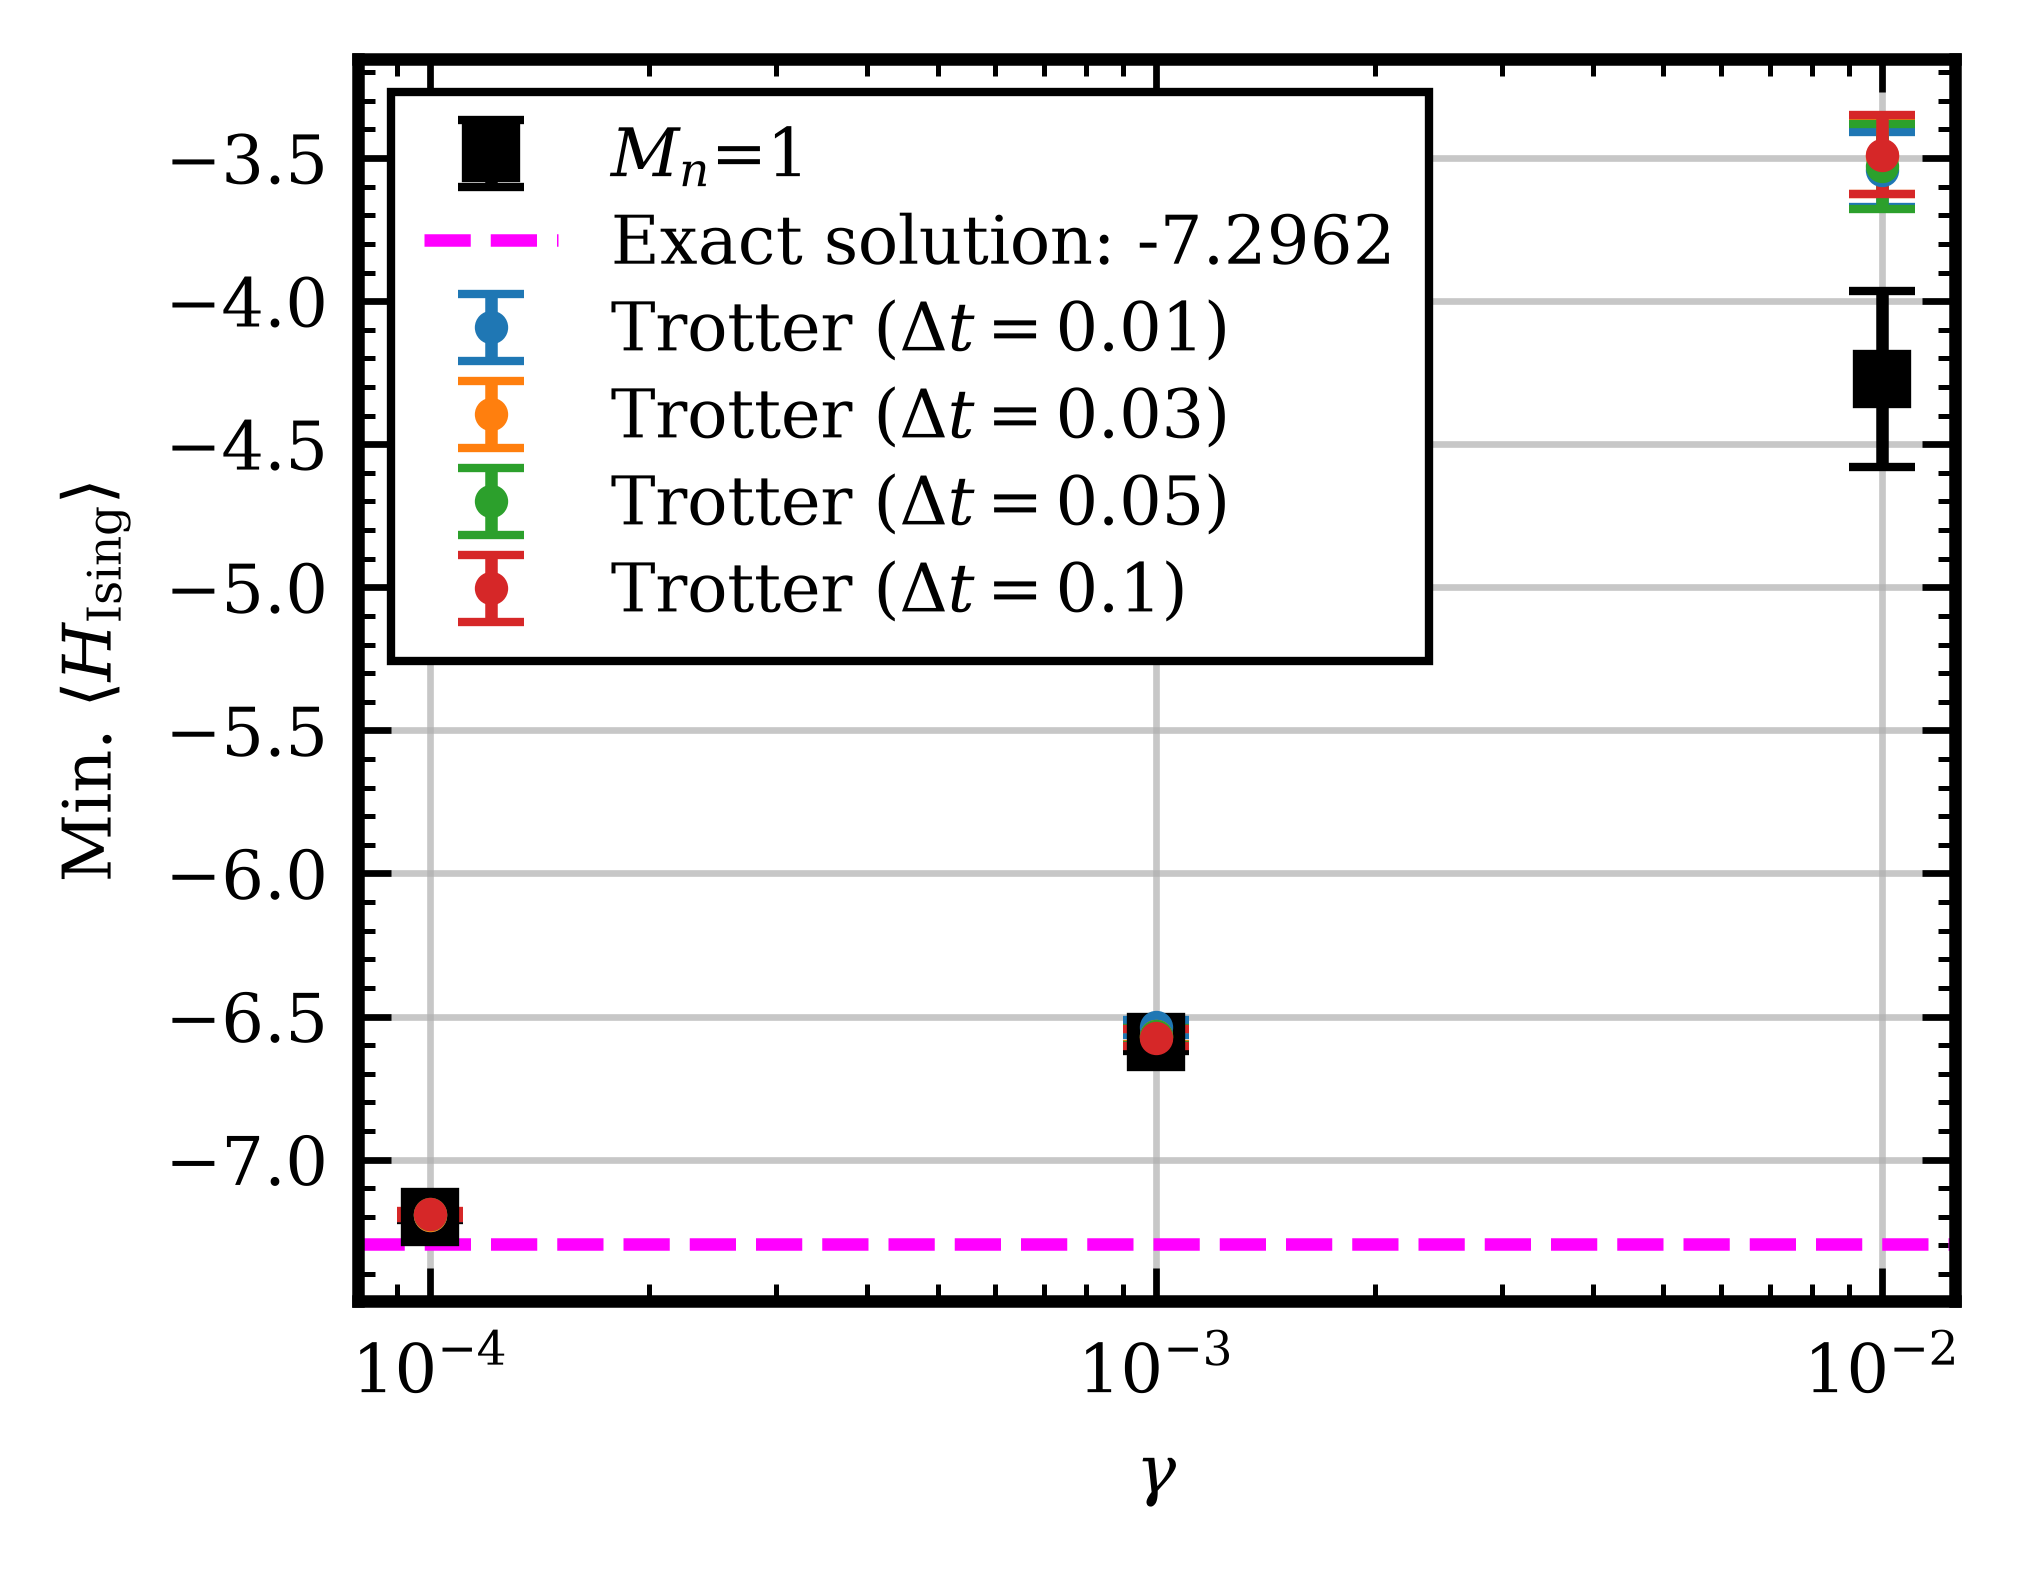

In [13]:
NOISE_KEYS = ['p0.0001', 'p0.001', 'p0.01']

def plot_trotter_vs_depol(
    processed:       dict,
    output_dir:      str,
    file_name:       str,
    exact_color:     str   = "magenta",
    figsize:         tuple = (7, 5),
    dpi:             int   = 600,
    save_format:     str   = "png",
    xlabel:          str   = r"$\gamma$",
    ylabel:          str   = r"Min. $\langle H_{\mathrm{Ising}} \rangle$",
    fontsize:        int   = 8,
    marker_size:     float = 6,
    capsize:         int   = 4,
    border_width:    float = 1.5,
    legend_loc:      str   = "best",
    show_plot:       bool  = False,
) -> plt.Figure:

    os.makedirs(output_dir, exist_ok=True)
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, layout="constrained")
    ax.set_axisbelow(True)

    legend_handles = []
    colors = ['black', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    # --- time-depol (exact evolution) ---
    x    = [processed[k]["time-depol"][0]["depol_p"]  for k in NOISE_KEYS]
    y    = [processed[k]["time-depol"][0]["vqe_mean"] for k in NOISE_KEYS]
    yerr = [processed[k]["time-depol"][0]["vqe_std"]  for k in NOISE_KEYS]
    h = ax.errorbar(x, y, yerr=yerr,
                    fmt="s", color='black', ecolor='black',
                    capsize=capsize, markersize=marker_size,
                    label=r'$M_n$=1', zorder=3)
    legend_handles.append(h)

    # --- exact solution line ---
    h_e = ax.axhline(EXACT_SOL, color=exact_color, linestyle='--',
                     linewidth=1.5, label=f'Exact solution: {EXACT_SOL:.4f}', zorder=2)
    legend_handles.append(h_e)

    # --- time-depol-trotter (one curve per del_t) ---
    all_del_t = sorted(set(
        d["del_t"]
        for k in NOISE_KEYS
        for d in processed[k]["time-depol-trotter"]
    ))

    for i, (del_t, color) in enumerate(zip(all_del_t, colors[1:])):
        x, y, yerr = [], [], []
        for noise_key in NOISE_KEYS:
            match = [d for d in processed[noise_key]["time-depol-trotter"] if d["del_t"] == del_t]
            if match:
                x.append(match[0]["depol_p"])
                y.append(match[0]["vqe_mean"])
                yerr.append(match[0]["vqe_std"])
        h = ax.errorbar(x, y, yerr=yerr,
                        fmt=".", color=color, ecolor=color,
                        capsize=capsize, markersize=marker_size,
                        label=f'Trotter ($\\Delta t = {del_t}$)', zorder=3)
        legend_handles.append(h)

    ax.set_xscale('log')
    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.tick_params(labelsize=fontsize)
    ax.grid(True, linestyle='-', alpha=0.7)
    ax.legend(
        handles=legend_handles,
        loc=legend_loc,
        fontsize=fontsize,
        frameon=True,
        framealpha=1.0,
        edgecolor='black',
        fancybox=False,
        borderpad=0.5,
        labelspacing=0.3,
    )
    for spine in ax.spines.values():
        spine.set_linewidth(border_width)

    path = os.path.join(output_dir, f"{os.path.splitext(file_name)[0]}.{save_format}")
    fig.savefig(path, format=save_format, dpi=dpi)
    print(f"✅ Saved: {path}")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)
    return fig


# --- call ---
plot_trotter_vs_depol(
    processed  = processed,
    figsize     = (3.25, 2.5),
    dpi         = 600,
    output_dir = MASTER_EXPORT_DIR,
    file_name  = "COMPARISION_TROTTER_VS_NO_TROTTER_6-QUBIT_VARY_GAMMA.png",
    show_plot  = False,
)